### This is a simple notebook used to model a linear relationship with ML algorithms.

It accompanies Chapter 1 of the book, but it is only used to derive the numbers quoted in the text.

Copyright: Viviana Acquaviva (2023)

License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/) 

revisions by Aaron Romanowsky

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
font = {'size'   : 16}
plt.rc('font', **font)
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('xtick.major', size=10, width=1.2)
plt.rc('ytick.major', size=10, width=1.2)
plt.rc('figure', figsize=[8,6])

In [3]:
np.random.seed(16) #set seed for reproducibility purposes
x = np.arange(10) 
y = 2*x + 5 + np.random.randn(10) #generate some data with random gaussian 
y = np.round(y,1) #This is done to match the notation in the book.

Text(0, 0.5, 'distance (m)')

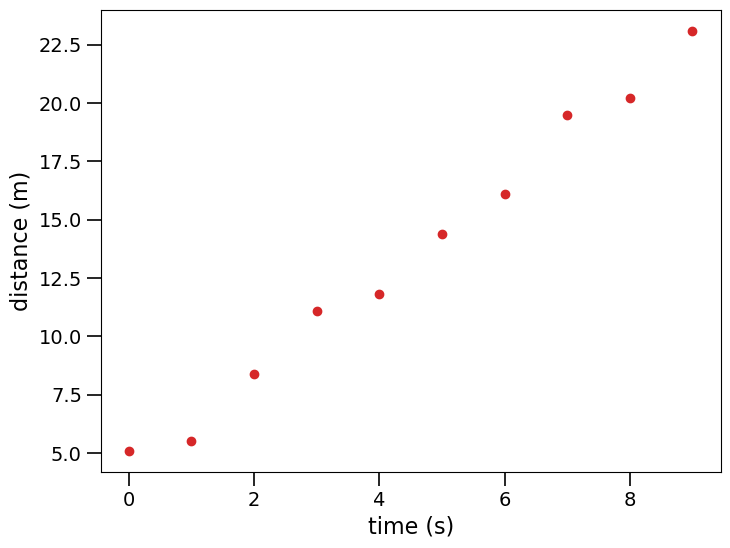

In [4]:
fig1 = plt.figure()
plt.scatter(x,y, c = 'C3')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')

#### Let's import a couple of simple machine learning models, and divide the learning set in a training and test subsets. 

In [5]:
from sklearn.tree import DecisionTreeRegressor

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
from sklearn.model_selection import train_test_split 

In [8]:
np.random.seed(10) #fix for reproducibility

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=3) #create train/test split

In [9]:
X_train, y_train

(array([6, 3, 1, 0, 7, 4, 9]),
 array([16.1, 11.1,  5.5,  5.1, 19.5, 11.8, 23.1]))

In [10]:
X_test

array([8, 2, 5])

In [11]:
treemodel = DecisionTreeRegressor() # default params

In [12]:
regmodel = LinearRegression() # default params

We build the model on the training set and use it to predict the output for the test set.

In [13]:
y_pred_tree = treemodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [14]:
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [15]:
print(y_test, y_pred_reg, y_pred_tree) #True/predicted by LR and DT respectively

[20.2  8.4 14.4] [20.89279279  8.41981982 14.65630631] [19.5  5.5 11.8]


Calculate Mean Squared Error for the two models

In [16]:
np.mean((y_test-y_pred_reg)**2)

np.float64(0.18201586721857252)

In [17]:
np.mean((y_test-y_pred_tree)**2)

np.float64(5.22)

Predict the value at t = 12 s with the two models

In [18]:
print(treemodel.predict(np.array(12).reshape(-1, 1)))
print(regmodel.predict(np.array(12).reshape(-1, 1)))

[23.1]
[29.20810811]


In [19]:
x_pred = np.linspace(0,10,101)
y_pred_reg2 = regmodel.predict(x_pred.reshape(-1, 1))
y_pred_tree2 = treemodel.predict(x_pred.reshape(-1, 1))

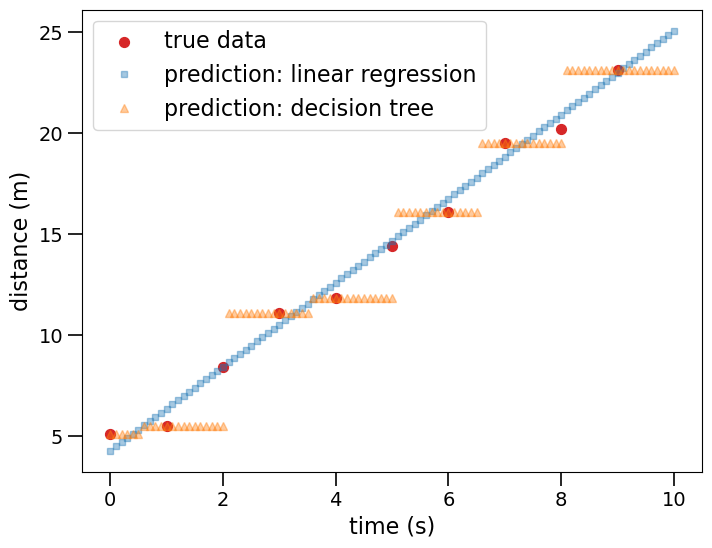

In [20]:
fig2 = plt.figure()
plt.scatter(x,y, c = 'C3', s=50, label='true data')
plt.plot(x_pred,y_pred_reg2, 's', ms=5, alpha=0.4, label='prediction: linear regression')
plt.plot(x_pred,y_pred_tree2, '^', ms=6, alpha=0.4, label='prediction: decision tree')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.legend(loc='best')
#plt.savefig('StraightLineML_fig2.png')